#                                             Online_foods_Project

## Import libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import	roc_curve,auc,roc_auc_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix ,ConfusionMatrixDisplay ,accuracy_score ,recall_score ,precision_score ,f1_score)

## Load Dataset

In [3]:
food_df = pd.read_csv('onlinefoods.csv')
food_df

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback,Unnamed: 12
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,Yes,Positive,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
383,23,Female,Single,Student,No Income,Post Graduate,2,12.9766,77.5993,560001,Yes,Positive,Yes
384,23,Female,Single,Student,No Income,Post Graduate,4,12.9854,77.7081,560048,Yes,Positive,Yes
385,22,Female,Single,Student,No Income,Post Graduate,5,12.9850,77.5533,560010,Yes,Positive,Yes
386,23,Male,Single,Student,Below Rs.10000,Post Graduate,2,12.9770,77.5773,560009,Yes,Positive,Yes


In [3]:
food_df.head(5)

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback,Unnamed: 12
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,Yes,Positive,Yes


In [4]:
food_df.tail(5)

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback,Unnamed: 12
383,23,Female,Single,Student,No Income,Post Graduate,2,12.9766,77.5993,560001,Yes,Positive,Yes
384,23,Female,Single,Student,No Income,Post Graduate,4,12.9854,77.7081,560048,Yes,Positive,Yes
385,22,Female,Single,Student,No Income,Post Graduate,5,12.9850,77.5533,560010,Yes,Positive,Yes
386,23,Male,Single,Student,Below Rs.10000,Post Graduate,2,12.9770,77.5773,560009,Yes,Positive,Yes
387,23,Male,Single,Student,No Income,Post Graduate,5,12.8988,77.5764,560078,Yes,Positive,Yes


In [5]:
#checking shape of the data
food_df.shape

(388, 13)

In [6]:
food_df.columns

Index(['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income',
       'Educational Qualifications', 'Family size', 'latitude', 'longitude',
       'Pin code', 'Output', 'Feedback', 'Unnamed: 12'],
      dtype='object')

In [7]:
food_df.dtypes

Age                             int64
Gender                         object
Marital Status                 object
Occupation                     object
Monthly Income                 object
Educational Qualifications     object
Family size                     int64
latitude                      float64
longitude                     float64
Pin code                        int64
Output                         object
Feedback                       object
Unnamed: 12                    object
dtype: object

## Handeling duplicate data

In [8]:
food_df.isnull().sum()

Age                           0
Gender                        0
Marital Status                0
Occupation                    0
Monthly Income                0
Educational Qualifications    0
Family size                   0
latitude                      0
longitude                     0
Pin code                      0
Output                        0
Feedback                      0
Unnamed: 12                   0
dtype: int64

## Drop duplicates value

In [9]:
food_df.duplicated().sum()

103

## Step-5: Do some data preprocessing
##### if any column corrupted
##### ex. Numerical values in categorical columns 
##### ex. Categorical values in numerical columns

In [10]:
food_df.drop_duplicates(inplace=True)

## Step-6: Drop the id type columns##### Which means a data has more unique labels
##### Drop the single value columns

In [11]:
food_df.shape

(285, 13)

In [12]:
food_df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback,Unnamed: 12
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,Yes,Positive,Yes


## tep-7: Categorical column Analysis

In [59]:
# Analysing categorical columns
categorical=food_df.select_dtypes(include='object').columns
categorical

Index(['Gender', 'Marital Status', 'Occupation', 'Monthly Income',
       'Educational Qualifications', 'Output', 'Feedback'],
      dtype='object')

In [14]:
unique=food_df['Gender'].unique()
unique


array(['Female', 'Male'], dtype=object)

In [15]:
food_df[['Gender']].value_counts()

Gender
Male      164
Female    121
Name: count, dtype: int64

In [16]:
# count=[]
# for i in unique:
#  con=food_df['Gender']==i
#  count.append(len(food_df[con]))

# count

In [17]:
# df=pd.DataFrame(zip(unique, count), columns=['labels','count'])
# df


In [18]:
# count=[]
# for i in unique:
#  con=food_df['Gender']==i
#  count.append(len(food_df[con]))

# count

## Barchart

In [19]:
categorical

Index(['Gender', 'Marital Status', 'Occupation', 'Monthly Income',
       'Educational Qualifications', 'Output', 'Feedback', 'Unnamed: 12'],
      dtype='object')

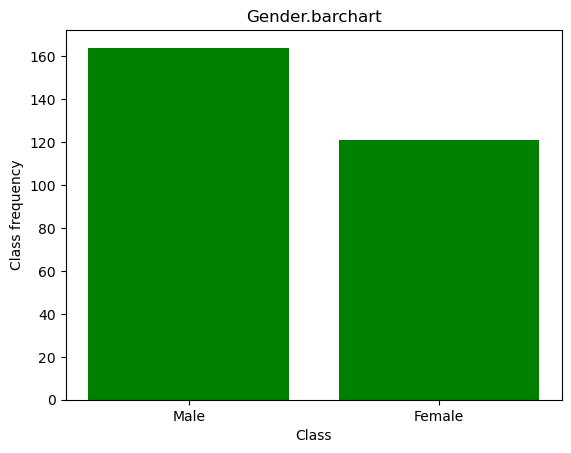

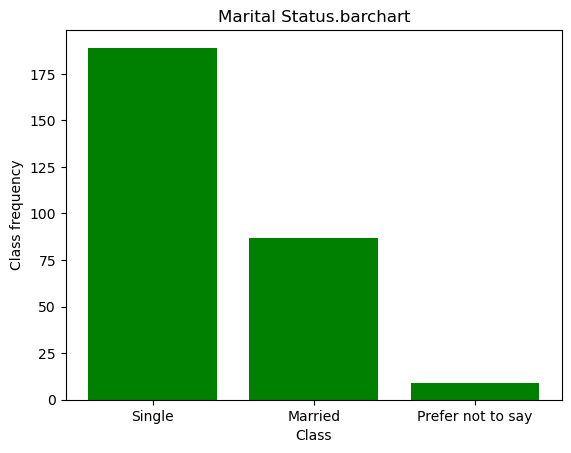

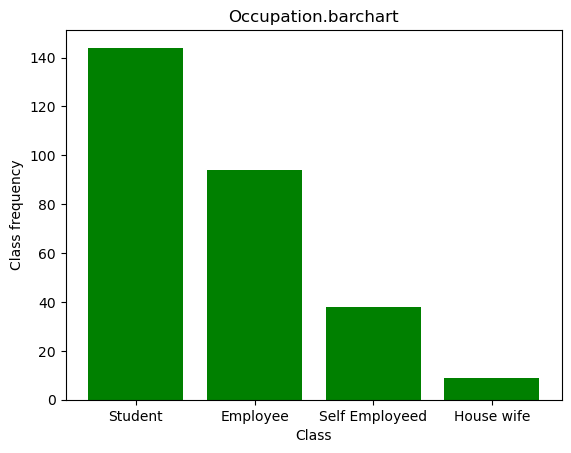

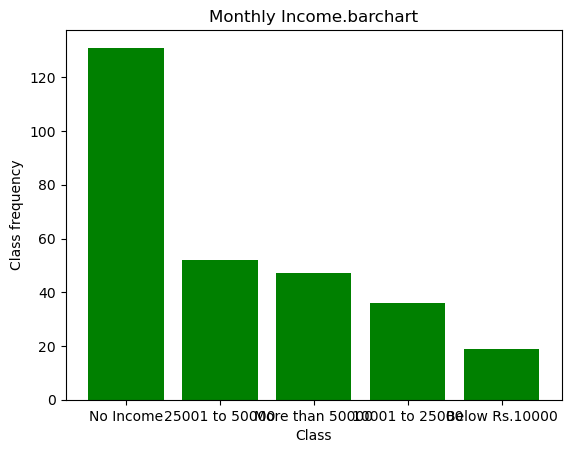

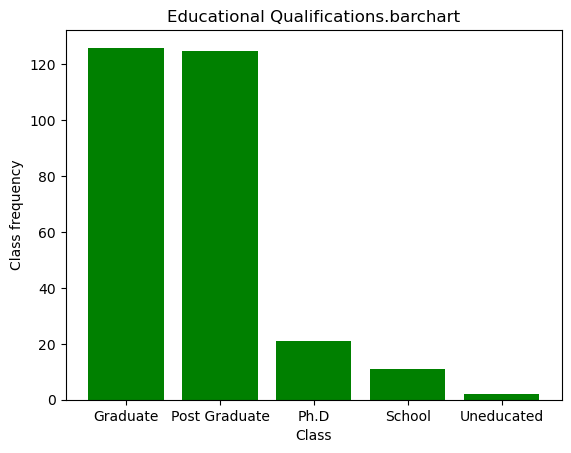

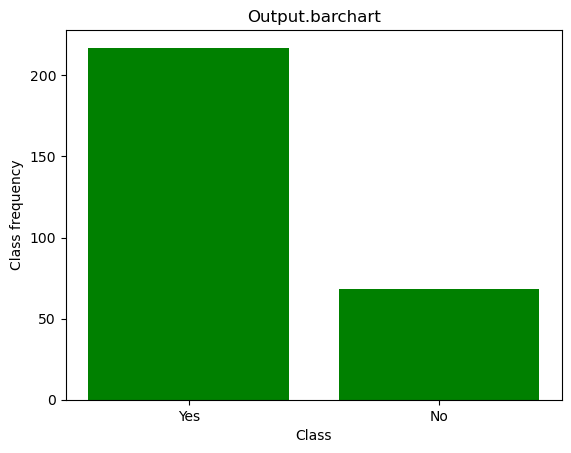

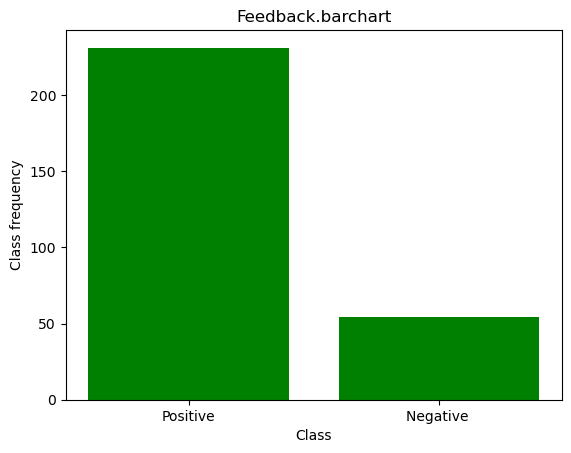

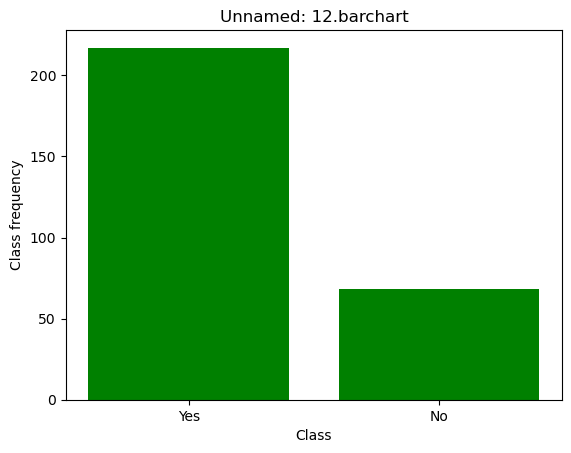

In [20]:
for i in categorical:
 keys=food_df[i].value_counts().keys()
 values=food_df[i].value_counts().values
 plt.bar(keys, values)
 plt.title(f'{i}.barchart')
 plt.xlabel('Class')
 plt.ylabel( 'Class frequency')
 plt.savefig('i.png')
 plt.bar(keys, values, color='green')   
 plt.show()

## Piechart

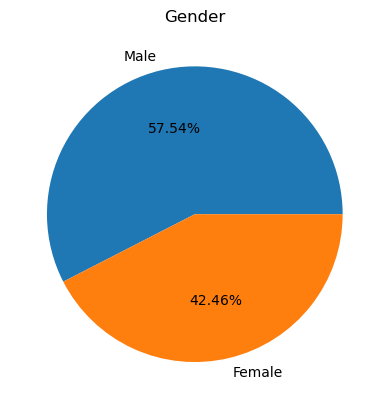

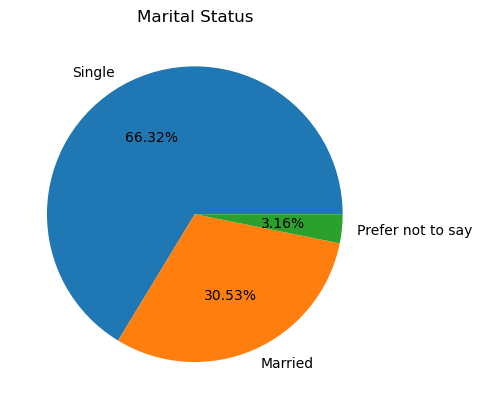

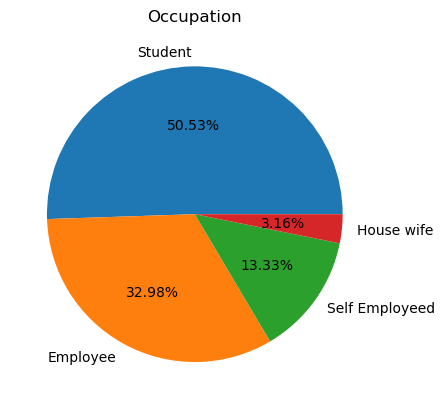

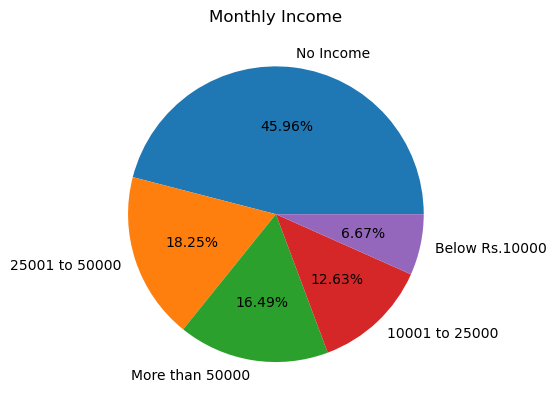

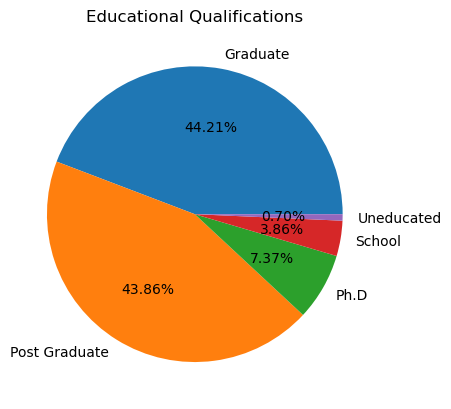

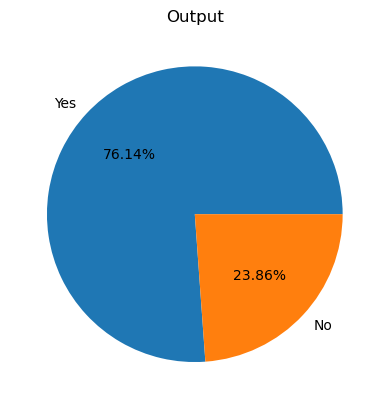

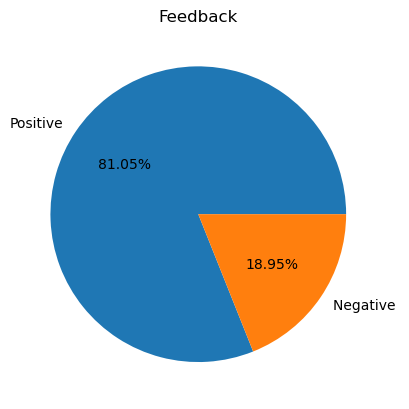

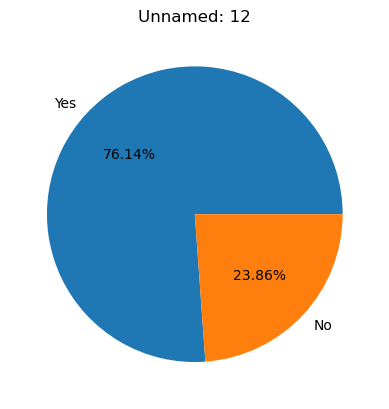

In [21]:
for i in categorical:
 keys=food_df[i].value_counts().keys()
 values=food_df[i].value_counts().values
 plt.pie(x=values, labels=keys, autopct='%0.2f%%')
 plt.savefig('i.png')
 plt.title(i) 
 plt.show()

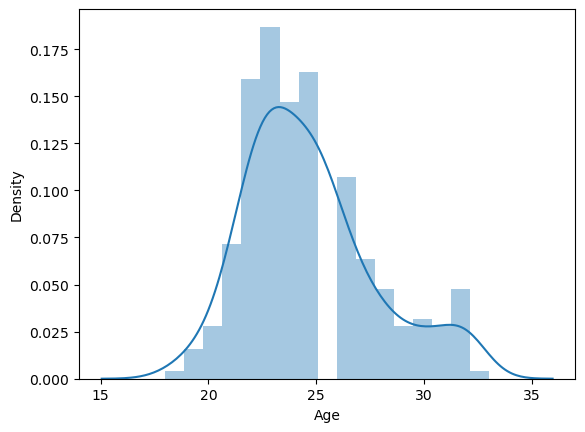

In [22]:
import warnings
warnings.filterwarnings('ignore')

# def distplots(col):
sns.distplot(food_df['Age'])
plt.show()

# for i in list(food_df.columns):
# distplots(i)

In [23]:
numerical=food_df.select_dtypes(exclude='object').columns
numerical


Index(['Age', 'Family size', 'latitude', 'longitude', 'Pin code'], dtype='object')

In [24]:
food_df.describe()

,Age,Family size,latitude,longitude,Pin code
count,285.000000,285.000000,285.000000,285.000000,285.000000
mean,24.677193,3.270175,12.973429,77.597593,560037.280702
std,3.040977,1.361178,0.043964,0.053557,30.738306
min,18.000000,1.000000,12.865200,77.484200,560001.000000
25%,23.000000,2.000000,12.943800,77.563500,560010.000000
50%,24.000000,3.000000,12.977000,77.587700,560028.000000
75%,26.000000,4.000000,12.998000,77.622700,560066.000000
max,33.000000,6.000000,13.102000,77.758200,560109.000000


## Distplot

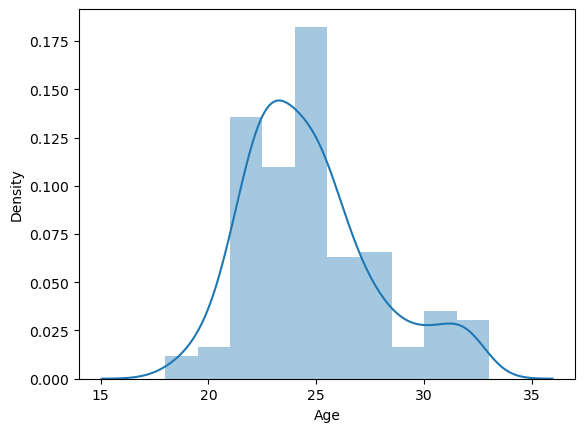

In [25]:
import warnings
warnings.filterwarnings('ignore')
sns.distplot(food_df['Age'], bins=10)
plt.show()

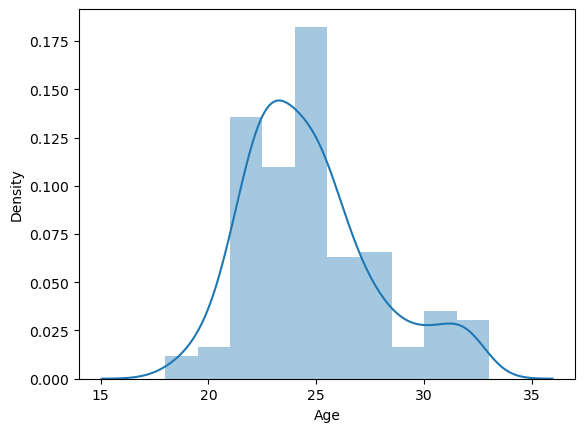

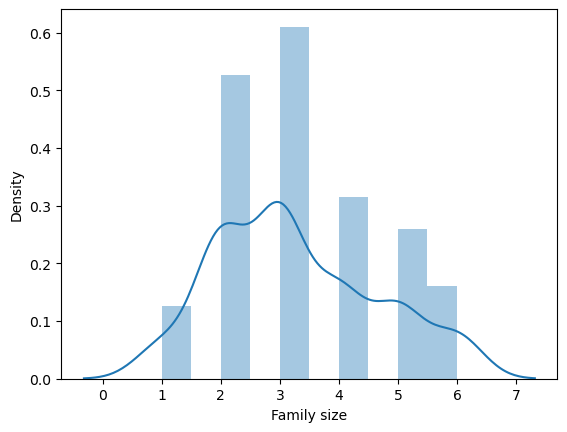

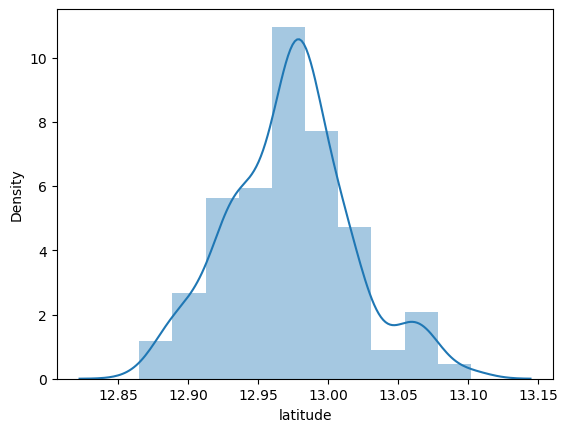

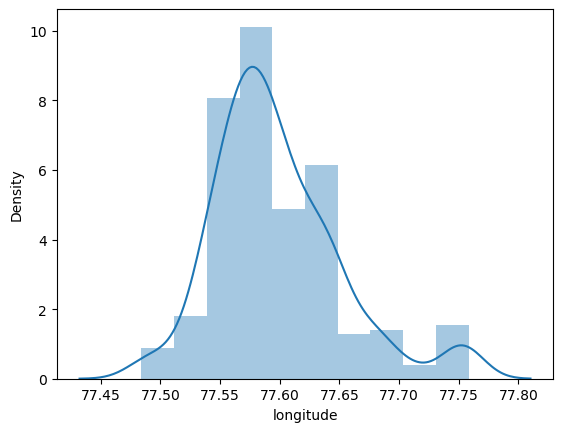

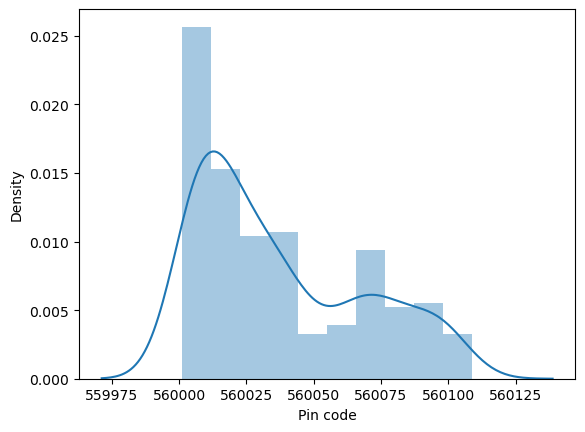

In [26]:
for i in numerical:
 sns.distplot(food_df[i], bins=10)
 plt.show()

## Step-9: Outlier Analysis


In [27]:
numerical

Index(['Age', 'Family size', 'latitude', 'longitude', 'Pin code'], dtype='object')

In [28]:
for i in food_df.columns:
    print("*" * 30, f"{i}", "*" * 30)  # Print column name dynamically
    
    # Print the number of unique values
    print(f"Number of unique values in '{i}': {food_df[i].nunique()}")
    
    # Print the unique values
    print(f"Unique values in '{i}': {food_df[i].unique()}")
    
    print("*" * 50)
    print("\n")

****************************** Age ******************************
Number of unique values in 'Age': 16
Unique values in 'Age': [20 24 22 27 23 21 28 25 32 30 31 26 18 19 33 29]
**************************************************


****************************** Gender ******************************
Number of unique values in 'Gender': 2
Unique values in 'Gender': ['Female' 'Male']
**************************************************


****************************** Marital Status ******************************
Number of unique values in 'Marital Status': 3
Unique values in 'Marital Status': ['Single' 'Married' 'Prefer not to say']
**************************************************


****************************** Occupation ******************************
Number of unique values in 'Occupation': 4
Unique values in 'Occupation': ['Student' 'Employee' 'Self Employeed' 'House wife']
**************************************************


****************************** Monthly Income ************

In [29]:
bal_data=food_df['Age']
# calculate the 1st and 3rd quartile
q1=round(np.quantile(bal_data,0.25),2)
q3=round(np.quantile(bal_data, 0.75),2)
# Compute the IQR and the lower and upper bounds
IQR=q3-q1
lb=q1-1.5*IQR
ub=q3+1.5*IQR
con1=food_df['Age']>lb
con2=food_df['Age']<ub
con3=con1&con2
count=len(food_df[con3])
non_outliers_data=food_df[con3]
non_outliers_data


,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback,Unnamed: 12
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,Yes,Positive,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
352,29,Female,Married,Employee,25001 to 50000,Graduate,4,12.9783,77.6408,560038,No,Positive,No
355,21,Male,Single,Student,No Income,Graduate,2,13.0012,77.5995,560046,No,Positive,No
369,30,Male,Married,Employee,More than 50000,Post Graduate,6,12.9369,77.6407,560095,Yes,Positive,Yes
374,21,Male,Single,Student,No Income,Graduate,3,13.0641,77.5931,560092,Yes,Negative,Yes


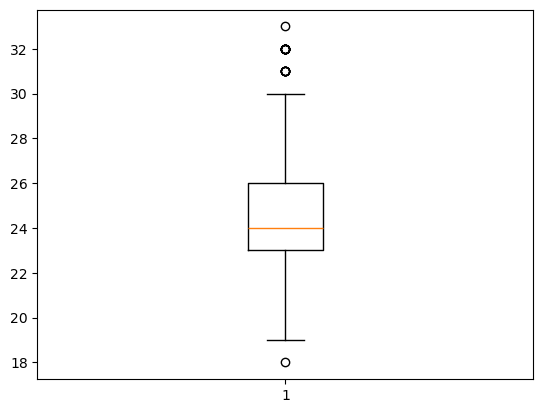

In [30]:
plt.boxplot(food_df['Age'])
plt.show()

In [2]:
for i in numerical:
    plt.boxplot(food_df[i])
    plt.show()

NameError: name 'numerical' is not defined

<Axes: xlabel='Family size'>

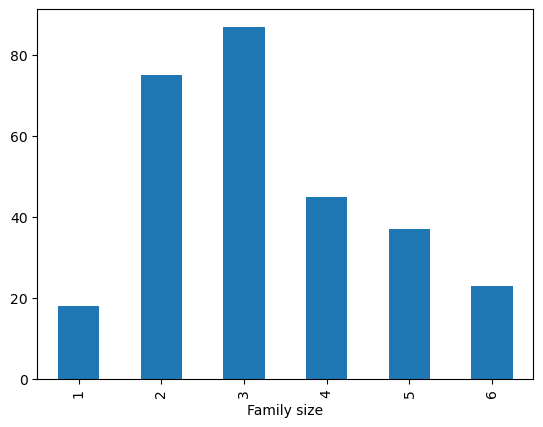

In [32]:
food_df["Family size"].value_counts().sort_index().plot(kind= "bar")

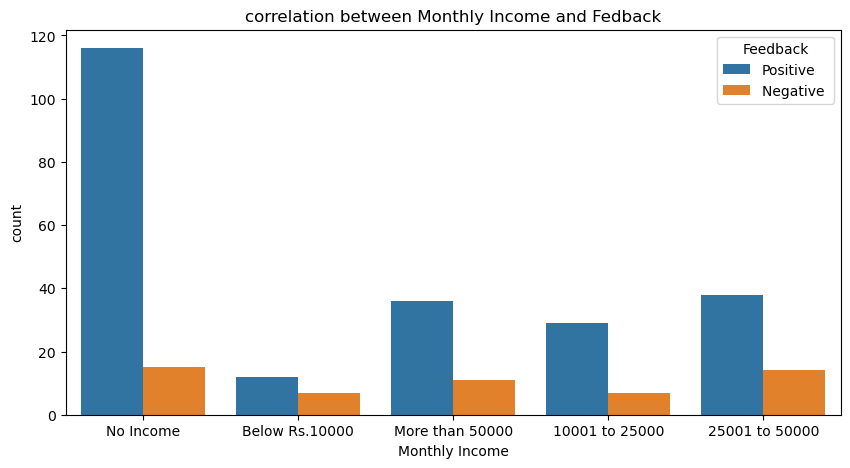

In [33]:
plt.figure(figsize=(10,5))
sns.countplot(data = food_df ,x= "Monthly Income" , hue ="Feedback")
plt.title("correlation between Monthly Income and Fedback")
plt.show()

In [34]:
# food_df["Target"] =  food_df.loc[:,"Unnamed: 12"]
food_df.drop("Unnamed: 12", axis=1 , inplace=True)

In [35]:
food_df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Yes,Negative
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,Yes,Positive
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,Yes,Positive


In [36]:
food_df.drop("latitude", axis=1 , inplace=True)
food_df.drop("longitude", axis=1 , inplace=True)

In [37]:
# lat_yes=food_df[food_df.Target == "Yes"  ]["latitude"]
# lat_no =food_df[food_df.Target == "No" ] ["latitude"]

# lo_yes=food_df[food_df.Target == "Yes"  ]["longitude"]
# lo_no =food_df[food_df.Target == "No" ] ["longitude"]

In [38]:
# sns.scatterplot(data = food_df ,x="latitude" , y="longitude"  ,hue='Target')

In [39]:
# sns.histplot(data= food_df  , x='Age' ,hue="Target",cumulative=False)

In [40]:
# food_df.drop(columns= ["Target"] ,inplace=True )

<Axes: xlabel='Monthly Income', ylabel='count'>

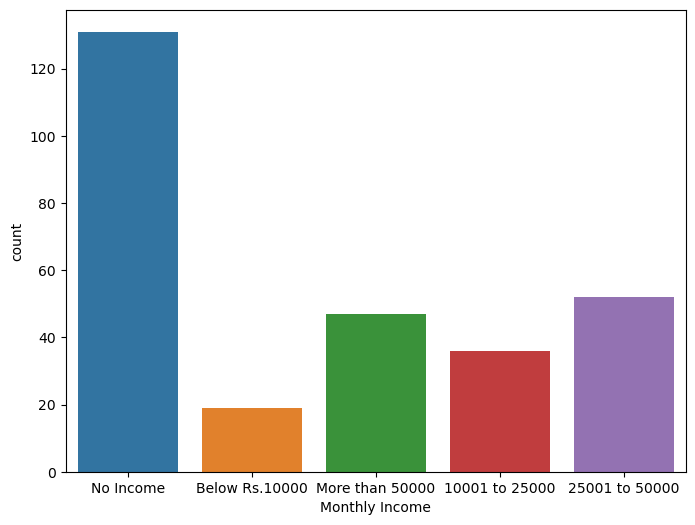

In [41]:
plt.figure(figsize=(8,6))
sns.countplot(x= food_df["Monthly Income"])

# Data Prepartion

In [42]:
food_df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Pin code,Output,Feedback
0,20,Female,Single,Student,No Income,Post Graduate,4,560001,Yes,Positive
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,560009,Yes,Positive
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,560017,Yes,Negative
3,22,Female,Single,Student,No Income,Graduate,6,560019,Yes,Positive
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,560010,Yes,Positive


## Spiltting Data into x & Y

In [43]:
x= food_df.drop("Output" , axis =1)
y= food_df["Output"]

## Label encoding on categorical columns on x & y

In [44]:
# performing label encoding on categorical columns
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=pd.DataFrame(le.fit_transform(y))

for i in x.columns:
    if i!= 'Age':
        x[i]=le.fit_transform(x[i])
    else:
        continue

In [45]:
x.head(1)

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Pin code,Feedback
0,20,0,2,3,4,2,3,0,1


In [46]:
y.head(1)

,0
0,1


In [58]:
# ordinary_data  =['Monthly Income','Educational Qualifications']

In [59]:
# cat1_=['Gender','Marital Status', 'Feedback', 'Occupation']

In [61]:
# lb= LabelEncoder()
# for col in ordinary_data:
#     x[col]=lb.fit_transform(x[col])

In [67]:
# x.info()

In [ ]:
#x=pd.get_dummies(x,drop_first=True)

## Spiltting x & y into x_train ,x_test , y_train , y_test

In [47]:
# splitting data into train test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=30)

## standard scaling on numerical column in x_train

In [ ]:
# standard scaling on numerical column in x_train
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
x_train['Age']=(ss.fit_transform(x_train[['Age']]))

## standard scaling on numerical column in x_test

In [70]:
# standard scaling on numerical column in x_test
x_test['Age']=(ss.fit_transform(x_test[['Age']]))

In [71]:
x_train.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Pin code,Feedback
65,0.124063,1,2,3,4,2,5,39,1
101,-0.533758,1,2,3,4,2,1,29,1
386,-0.533758,1,2,3,2,2,1,8,1
73,-0.533758,1,2,3,4,2,1,59,1
288,0.124063,0,2,3,4,2,2,13,1


In [72]:
x_test.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Pin code,Feedback
69,-0.297560,0,0,0,3,1,3,3,1
239,-0.630126,0,2,3,4,2,2,68,1
62,-0.630126,1,2,3,1,2,0,69,1
224,0.035007,0,0,3,4,2,1,50,1
131,2.362973,0,0,0,3,0,0,2,1


# Modeling(Preprocessing)

## LogisticRegression

In [48]:
model1 =LogisticRegression()
model1.fit(x_train,y_train)

LogisticRegression()

recall acc for train :  0.8723404255319149
precision for train :  0.9534883720930233
f1_score for train :  0.9111111111111112
acc :  0.8596491228070176


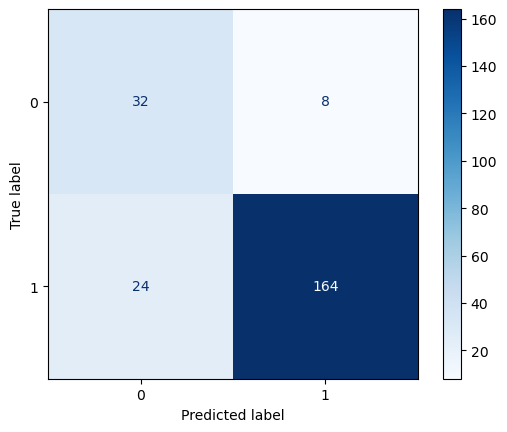

In [74]:
y_pred_train = model1.predict(x_train)
cm = confusion_matrix(y_pred_train,y_train )

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

print("recall acc for train : " , recall_score(y_pred_train,y_train))
print("precision for train : " ,precision_score(y_pred_train,y_train))
print("f1_score for train : " ,f1_score(y_pred_train,y_train))
print("acc : " ,accuracy_score(y_pred_train,y_train))
disp.plot(cmap='Blues')

plt.show()

recall acc for train :  0.9090909090909091
precision for train :  0.8888888888888888
f1_score for train :  0.8988764044943819
acc :  0.8421052631578947


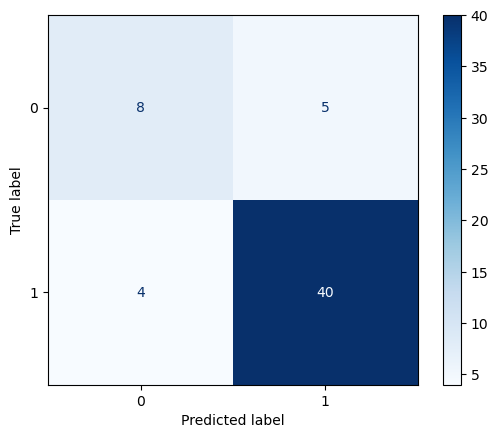

In [75]:
y_pred_test = model1.predict(x_test)
cm = confusion_matrix(y_pred_test,y_test )

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

print("recall acc for train : " , recall_score(y_pred_test,y_test))
print("precision for train : " ,precision_score(y_pred_test,y_test))
print("f1_score for train : " ,f1_score(y_pred_test,y_test))
print("acc : " ,accuracy_score(y_pred_test,y_test))

disp.plot(cmap='Blues')

plt.show()

## Decision Tree

recall acc for train :  0.873015873015873
precision for train :  0.9593023255813954
f1_score for train :  0.9141274238227148
acc :  0.8640350877192983


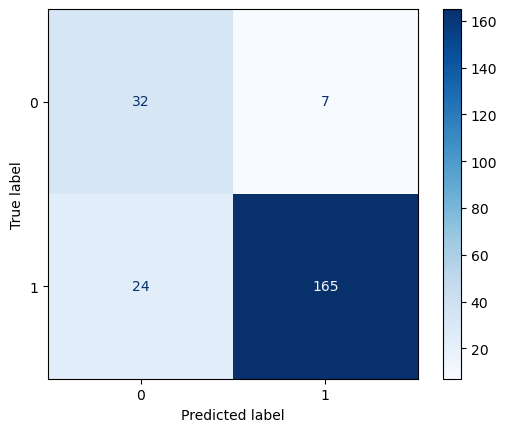

In [76]:
#Decision Tree
model2 =DecisionTreeClassifier(max_depth=2,criterion='entropy')
model2.fit(x_train,y_train)

y_pred_train = model2.predict(x_train)
cm = confusion_matrix(y_pred_train,y_train )

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

print("recall acc for train : " , recall_score(y_pred_train,y_train))
print("precision for train : " ,precision_score(y_pred_train,y_train))
print("f1_score for train : " ,f1_score(y_pred_train,y_train))
print("acc : " ,accuracy_score(y_pred_train,y_train))
disp.plot(cmap='Blues')

plt.show()

recall acc for train :  0.9090909090909091
precision for train :  0.8888888888888888
f1_score for train :  0.8988764044943819
acc :  0.8421052631578947


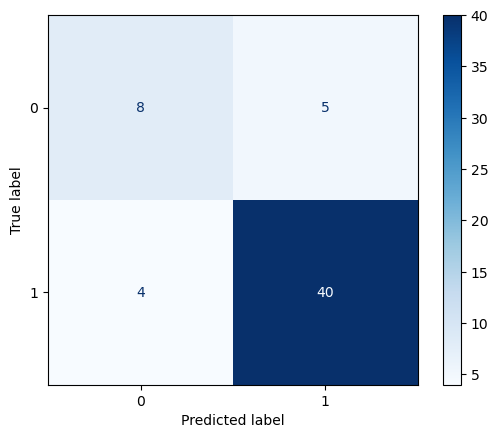

In [78]:
y_pred_test = model1.predict(x_test)
cm = confusion_matrix(y_pred_test,y_test )

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

print("recall acc for train : " , recall_score(y_pred_test,y_test))
print("precision for train : " ,  precision_score(y_pred_test,y_test))
print("f1_score for train : " ,   f1_score(y_pred_test,y_test))
print("acc : " ,accuracy_score(y_pred_test,y_test))

disp.plot(cmap='Blues')

plt.show()

## Random Forest

In [79]:
# Create Random Forest Classifier instance
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model
rf_classifier.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [49]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)


x_train shape: (228, 9)
y_train shape: (228, 1)


recall acc for train :  1.0
precision for train :  1.0
f1_score for train :  1.0
acc :  1.0


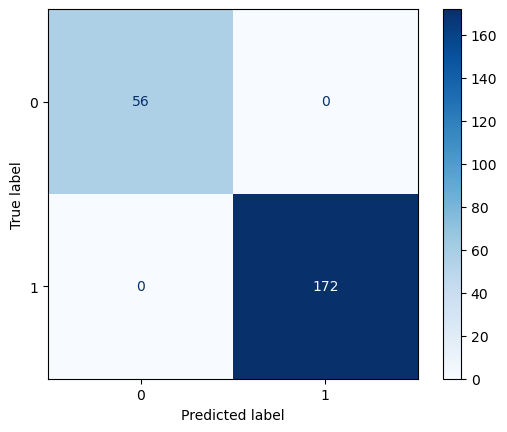

In [80]:
rf_classifier.fit(x_train,y_train)

y_pred_train = rf_classifier.predict(x_train)
cm = confusion_matrix(y_pred_train,y_train )

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

print("recall acc for train : " , recall_score(y_pred_train,y_train))
print("precision for train : " ,precision_score(y_pred_train,y_train))
print("f1_score for train : " ,f1_score(y_pred_train,y_train))
print("acc : " ,accuracy_score(y_pred_train,y_train))
disp.plot(cmap='Blues')

plt.show()

In [81]:
number_trees=[i for i in range(100,2100,100)]
oob_errors=[]

for i in number_trees:
    rfc=RandomForestClassifier(n_estimators=i, oob_score=True, random_state=42, bootstrap=True)
    rfc.fit(x_test,y_test)
    y_test_predict=rfc.predict(x_test)
    oob_errors.append(1 - rfc.oob_score_)

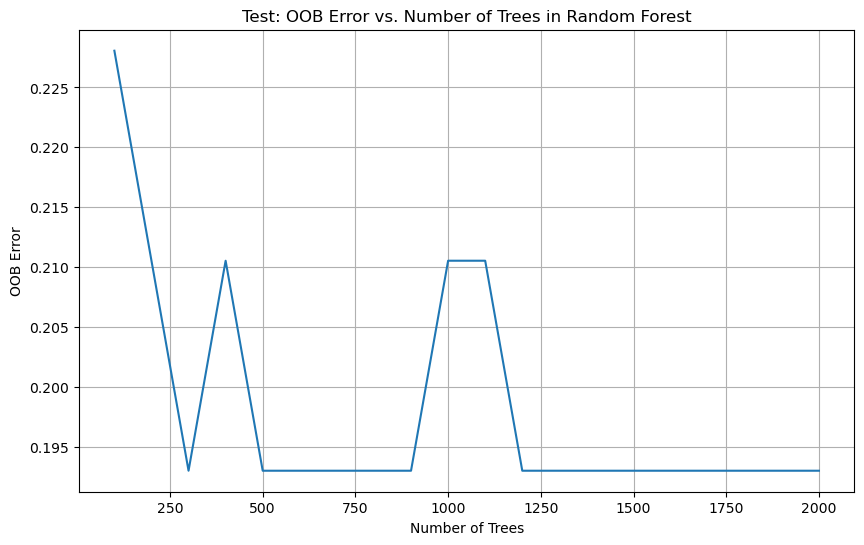

In [82]:
plt.figure(figsize=(10, 6))
plt.plot(number_trees, oob_errors)
plt.title("Test: OOB Error vs. Number of Trees in Random Forest")
plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.grid()
plt.show()

In [56]:
import numpy as np
def calculate_acc(xtrain ,x_test ,y_train ,y_test):
    models =[LogisticRegression(),DecisionTreeClassifier(),RandomForestClassifier()]
    data_frame = pd.DataFrame()
    acc =[]
    recall =[]
    precision =[]
    f1=[]
    for mod in models :
        model_ = mod
        model_.fit(x_train ,y_train)
        
        y_pred_test =model_.predict(x_test)
        acc.append(np.round(accuracy_score(y_pred_test,y_test),2))
        recall.append(np.round(recall_score(y_pred_test,y_test),2))  
        precision.append(precision_score(y_pred_test,y_test))
        f1.append(f1_score(y_pred_test,y_test).round(2))
    
    
    tabel =pd.DataFrame(index=["LogisticRegression","DecisionTreeClassifier" ,"RandomForestClassifier"],
                        columns=["acc" ,"recall","precision","F1"] )
    tabel["acc"]    = acc
    tabel["recall"] =recall
    tabel["precision"] = precision 
    tabel["F1"] =f1
    return tabel
    print("Accuracy Measurement")
calculate_acc(x_train, x_test, y_train, y_test)

,acc,recall,precision,F1
LogisticRegression,0.84,0.91,0.888889,0.90
DecisionTreeClassifier,0.74,0.86,0.800000,0.83
RandomForestClassifier,0.82,0.87,0.911111,0.89


In [11]:
df.head()

0    20
1    24
2    22
3    22
4    22
Name: Age, dtype: int64

In [12]:
print(sw)

0.8098768724480562
